In [1]:
import polars as pl
import torch
import torch.nn as nn
import umap
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, adjusted_rand_score
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import seaborn as sns
from amaretto_mlp import *
from utils_b import *
from autoencoder import *
from model import *
from visualization import *
from triplet_loss import *

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
pl.Config.set_tbl_cols(150) 

polars.config.Config

In [3]:
df = pl.read_parquet("amaretto_transformed_scaled.pq")
df = df.with_columns(((pl.col('hour') >= 2) & (pl.col('hour') < 5)).alias('unusual_hour'))
df_train, df_val, df_test = split_data(df)

#columns_to_drop = ['id', 'Anomaly', 'Anomaly_bin', 'Originator', 'datetime']
#columns_to_drop = ['id', 'Anomaly', 'Anomaly_bin', 'Originator', 'datetime', 'day_of_week', 'day_of_month', 'hour', 'minute']
columns_to_drop = ['id', 'Anomaly', 'Anomaly_bin', 'Originator', 'datetime', 'day_of_week', 'day_of_month', 'hour', 'minute', 'day_of_month_cos', 'minute_cos', 'day_of_month_sin', 'minute_sin']


target_column = 'Anomaly_bin'
y_train = df_train.select(target_column).to_numpy().flatten()
y_train_anomalies = df_train.select('Anomaly').to_numpy().flatten()
df_train = df_train.drop(columns_to_drop)
X_train = df_train.to_numpy()
y_val = df_val.select(target_column).to_numpy().flatten()
X_val = df_val.drop(columns_to_drop).to_numpy()
y_test = df_test.select(target_column).to_numpy().flatten()
y_test_anomalies = df_test.select('Anomaly').to_numpy().flatten()

X_test = df_test.drop(columns_to_drop).to_numpy()

train_dataset = AmarettoDataset(X_train, y_train)
val_dataset = AmarettoDataset(X_val, y_val)
test_dataset = AmarettoDataset(X_test, y_test)
feature_names = df_train.columns
print(X_train.shape)
print(X_test.shape)

(24451934, 118)
(2765755, 118)


In [4]:
train_loader = DataLoader(train_dataset, batch_size=512, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=256, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=256, num_workers=2)
input_dim = X_train.shape[1]
df_train, df_val, df_test = split_data(df)
print(len(train_loader))

47758


In [5]:
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(class_weights, dtype=torch.float)
class_weights

tensor([  0.5014, 180.1141])

In [6]:
model = ProtoPNet(input_dim, hidden_layers=[64, 64], num_prototypes=15, num_neg=10, num_classes=2, latent_dim=16)

In [7]:
model

ProtoPNet(
  (encoder): Encoder(
    (network): Sequential(
      (0): Linear(in_features=118, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Tanh()
      (4): Linear(in_features=64, out_features=16, bias=True)
    )
  )
  (decoder): Decoder(
    (network): Sequential(
      (0): Linear(in_features=16, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Tanh()
      (4): Linear(in_features=64, out_features=118, bias=True)
    )
  )
  (proto_layer): PrototypeLayer()
  (last_layer): Linear(in_features=15, out_features=2, bias=False)
)

In [8]:
model.proto_layer.prototype_labels

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1])

In [9]:
samples = []
labels = []
num_per_type = 5
for anomaly_type in range(1,6):
    indices = np.where(y_train_anomalies == anomaly_type)[0]
    chosen = np.random.permutation(indices)[:num_per_type]

    # Add to the list
    samples.append(torch.tensor(X_train[chosen], dtype=torch.float32))
    labels.append(torch.tensor(y_train_anomalies[chosen], dtype=torch.long))

X_triplet = torch.cat(samples, dim=0)
y_triplet = torch.cat(labels)


In [51]:
lambda_triplet_values = [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 100.0]


for lambda_triplet in lambda_triplet_values:
    model = ProtoPNet(input_dim, hidden_layers=[64, 64], num_prototypes=15, num_neg=10, num_classes=2, latent_dim=16)
    print(f"\n Training with lambda_triplet = {lambda_triplet}")
    
    # Format lambda value for filename (e.g., 0.3 → "0_3")
    lambda_str = str(lambda_triplet).replace('.', '_')
    
    # Construct unique filename for this experiment
    filepath = f"model_ppnet_best_triplet_10_lambda_{lambda_str}.pth"
    print(f"Saving to {filepath}")
    train_protopnet_triplet(model, 
                            train_loader, 
                            val_loader, 
                            epochs=6, 
                            X_triplet=X_triplet, 
                            y_triplet=y_triplet, 
                            lr=0.0001, 
                            class_weights=class_weights, 
                            lambda_triplet=lambda_triplet, 
                            lambda_clst=0.8, 
                            lambda_sep=0.08,
                            filepath=filepath)


 Training with lambda_triplet = 0.5
Saving to model_ppnet_best_triplet_10_lambda_0_5.pth
0.5

Epoch 1/6


Epoch 1/6 [Training]:   0%|          | 0/47758 [00:00<?, ?it/s]

Phase 1 - Training Loss: -0.3808
Phase 2 - Prototype Projection Completed
Epoch 1/1, Loss: 0.25530754487353374
Phase 3 - Last Layer Optimization Completed
Epoch 1: Val Loss = 0.1648
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   2479693
           1       0.39      0.93      0.55      6708

    accuracy                           1.00   2486401
   macro avg       0.70      0.96      0.77   2486401
weighted avg       1.00      1.00      1.00   2486401

New best model saved with Macro F1 = 0.7739

Epoch 2/6


Epoch 2/6 [Training]:   0%|          | 0/47758 [00:00<?, ?it/s]

Phase 1 - Training Loss: -0.3559
Phase 2 - Prototype Projection Completed
Epoch 1/1, Loss: 0.12630250464643397
Phase 3 - Last Layer Optimization Completed
Epoch 2: Val Loss = 0.0652
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   2479693
           1       0.41      0.95      0.57      6708

    accuracy                           1.00   2486401
   macro avg       0.71      0.98      0.79   2486401
weighted avg       1.00      1.00      1.00   2486401

New best model saved with Macro F1 = 0.7864

Epoch 3/6


...

Phase 1 - Training Loss: -1.5220
Phase 2 - Prototype Projection Completed
Epoch 1/1, Loss: 0.11443072086092779
Phase 3 - Last Layer Optimization Completed
Epoch 4: Val Loss = 0.0720
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   2479693
           1       0.69      0.95      0.80      6708

    accuracy                           1.00   2486401
   macro avg       0.85      0.97      0.90   2486401
weighted avg       1.00      1.00      1.00   2486401

New best model saved with Macro F1 = 0.9002

Epoch 5/6


Epoch 5/6 [Training]:   0%|          | 0/47758 [00:00<?, ?it/s]

Phase 1 - Training Loss: -2.3232
Phase 2 - Prototype Projection Completed
Epoch 1/1, Loss: 0.12451145402108382
Phase 3 - Last Layer Optimization Completed
Epoch 5: Val Loss = 0.0687
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   2479693
           1       0.72      0.95      0.82      6708

    accuracy                           1.00   2486401
   macro avg       0.86      0.97      0.91   2486401
weighted avg       1.00      1.00      1.00   2486401

New best model saved with Macro F1 = 0.9089

Epoch 6/6


Epoch 6/6 [Training]:   0%|          | 0/47758 [00:00<?, ?it/s]

Phase 1 - Training Loss: -3.2436
Phase 2 - Prototype Projection Completed
Epoch 1/1, Loss: 0.1277892098348191
Phase 3 - Last Layer Optimization Completed
Epoch 6: Val Loss = 0.0804
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   2479693
           1       0.75      0.94      0.83      6708

    accuracy                           1.00   2486401
   macro avg       0.87      0.97      0.92   2486401
weighted avg       1.00      1.00      1.00   2486401

New best model saved with Macro F1 = 0.9163


In [ ]:
lambda_triplet = 0.5
filepath = "model_ppnet_best_triplet_10_lambda_0_5.pth"
train_protopnet_triplet(model, 
                        train_loader, 
                        val_loader, 
                        epochs=6, 
                        X_triplet=X_triplet, 
                        y_triplet=y_triplet, 
                        lr=0.0001, 
                        class_weights=class_weights, 
                        lambda_triplet=lambda_triplet, 
                        lambda_clst=0.8, 
                        lambda_sep=0.2,
                        filepath=filepath)

### Metrics for all lambda_triplet values

In [31]:
lambda_triplet_values = [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 100.0]


for lambda_triplet in lambda_triplet_values:
    model = ProtoPNet(input_dim, hidden_layers=[64, 64], num_prototypes=15, num_neg=10, num_classes=2, latent_dim=16)
    print(f"\n Metrics for λ_triplet = {lambda_triplet}")
    
    lambda_str = str(lambda_triplet).replace('.', '_')
    filepath = f"model_ppnet_best_triplet_lambda_{lambda_str}.pth"
    model.load_state_dict(torch.load(filepath))

    model.eval()
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    with torch.no_grad():
        _, z_train, _, y_logits = model(X_train_tensor)
        y_probs_train = F.softmax(y_logits, dim=1)
        y_pred_train = torch.argmax(y_probs_train, dim=1)
    y_pred_train = y_pred_train.cpu().numpy()
    y_probs_train = y_probs_train.cpu().numpy()
    z_train = z_train.cpu().numpy()

    model.eval()
    X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
    with torch.no_grad():
        _, z_val, _, y_logits = model(X_val_tensor)
        y_probs_val = F.softmax(y_logits, dim=1)
        y_pred_val = torch.argmax(y_probs_val, dim=1)
    y_pred_val = y_pred_val.cpu().numpy()
    y_probs_val = y_probs_val.cpu().numpy()
    z_val = z_val.cpu().numpy()
    
    model.eval()
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    with torch.no_grad():
        _, z_test, _, y_logits = model(X_test_tensor)
        y_probs_test = F.softmax(y_logits, dim=1)
        y_pred_test = torch.argmax(y_probs_test, dim=1)
    y_pred_test = y_pred_test.cpu().numpy()
    y_probs_test = y_probs_test.cpu().numpy()
    z_test = z_test.cpu().numpy()
    
    print(f"Training data:")

    print(classification_report(y_train, y_pred_train, digits=4))

    print(f"Validation data:")

    print(classification_report(y_val, y_pred_val, digits=4))

    print(f"Testing data:")

    print(classification_report(y_test, y_pred_test, digits=4))

    


 Metrics for λ_triplet = 0.01
Training data:
              precision    recall  f1-score   support

           0     0.9999    0.9711    0.9853  24384055
           1     0.0839    0.9511    0.1542     67879

    accuracy                         0.9710  24451934
   macro avg     0.5419    0.9611    0.5697  24451934
weighted avg     0.9973    0.9710    0.9830  24451934

Validation data:
              precision    recall  f1-score   support

           0     0.9998    0.9992    0.9995   2479693
           1     0.7661    0.9290    0.8397      6708

    accuracy                         0.9990   2486401
   macro avg     0.8829    0.9641    0.9196   2486401
weighted avg     0.9992    0.9990    0.9991   2486401

Testing data:
              precision    recall  f1-score   support

           0     0.9999    0.9979    0.9989   2759074
           1     0.5228    0.9680    0.6790      6681

    accuracy                         0.9978   2765755
   macro avg     0.7614    0.9829    0.8389   27657

### UMAP and TSNE reduction for λ_triplet = 0.5 

In [49]:
model.load_state_dict(torch.load("model_ppnet_best_triplet_lambda_0_5.pth"))

<All keys matched successfully>

In [33]:
print(confusion_matrix(y_test, y_pred_test))


[[2753529    5545]
 [    209    6472]]


In [51]:
z_sampled, y_true_sampled, selected_indices = sample_data(z_test, y_test, n_samples=70000, anomaly_ratio=0.1)
y_pred_sampled = y_pred_test[selected_indices]
y_test_anomalies_sampled = y_test_anomalies[selected_indices]
print(z_sampled.shape)

[6681]
63000
2759074
63000
(69681, 16)


In [37]:
z_sampled, y_true_sampled, selected_indices = sample_data(z_train, y_train, n_samples=200000, anomaly_ratio=0.2)
y_pred_sampled = y_pred_train[selected_indices]
y_train_anomalies_sampled = y_train_anomalies[selected_indices]
print(z_sampled.shape)

[67879]
160000
24384055
160000
torch.Size([200000, 16])


#### Training data

In [38]:
reducer = umap.UMAP()
embedding = reducer.fit_transform(z_sampled)
embedding.shape

/home/darosali/BP/amaretto/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


(200000, 2)

In [39]:
prototypes = model.proto_layer.prototypes.detach().cpu().numpy()
prototype_embedding = reducer.transform(prototypes) 
prototype_embedding.shape

/home/darosali/BP/amaretto/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


(15, 2)

In [35]:
model.eval()
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
with torch.no_grad():
    z_train = model.encoder(X_train_tensor)
    prototypes = model.proto_layer.prototypes.detach()

# Compute L2 distances between prototypes and training latent space
dists = torch.cdist(prototypes, z_train)  # Shape: (num_prototypes, num_train_samples)

# Find closest training point for each prototype
closest_indices = torch.argmin(dists, dim=1)
closest_points = z_train[closest_indices]

distances = torch.min(dists, dim=1)[0]

# for i, dist in enumerate(distances):
#     print(f"Prototype {i}: Closest training point at index {closest_indices[i]}, Distance: {dist.item():.4f}")
print(f"Anomaly prototypes indexes: {y_train_anomalies[closest_indices[-5:]]}")

Anomaly prototypes indexes: [1 2 3 4 5]


In [36]:
all_labels = np.array([0, 1, 2, 3, 4, 5])
set1_colors = sns.color_palette("Set1", n_colors=len(all_labels))
custom_palette = ["#A0A0A0"] + set1_colors[1:]
proto_colors = [custom_palette[label] for label in y_train_anomalies[closest_indices]]

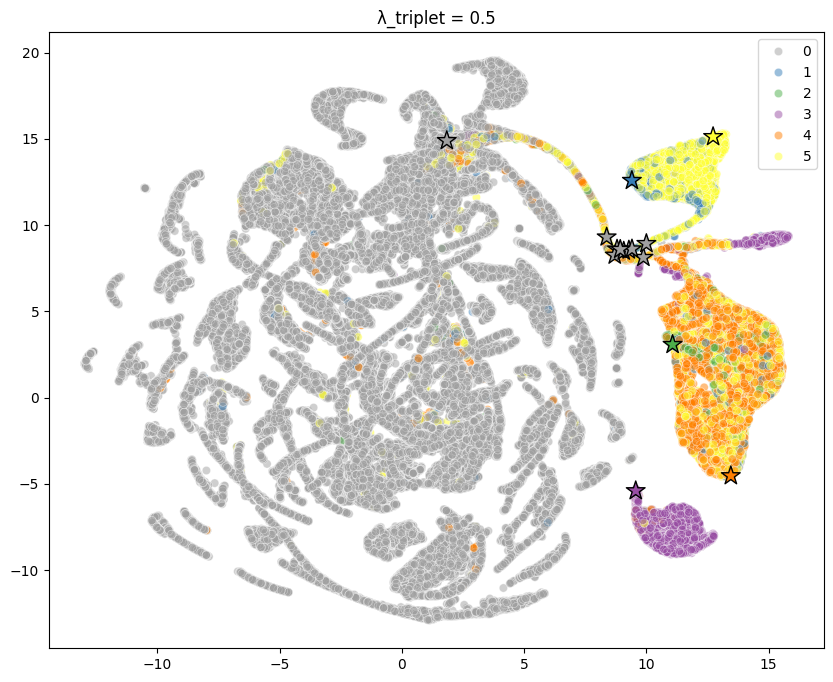

In [40]:
# Plot
plt.figure(figsize=(10, 8))
sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], hue=y_train_anomalies_sampled, alpha=0.5, palette=custom_palette)

plt.scatter(prototype_embedding[:, 0], prototype_embedding[:, 1], c=proto_colors, marker='*', s=200, edgecolors='black')

#plt.xlabel("UMAP Dimension 1")
#plt.ylabel("UMAP Dimension 2")
plt.title("λ_triplet = 0.5")
plt.legend()
#plt.savefig(f"figs/ppnet/triplet_lambda_0_5_sampled.png")
plt.show()

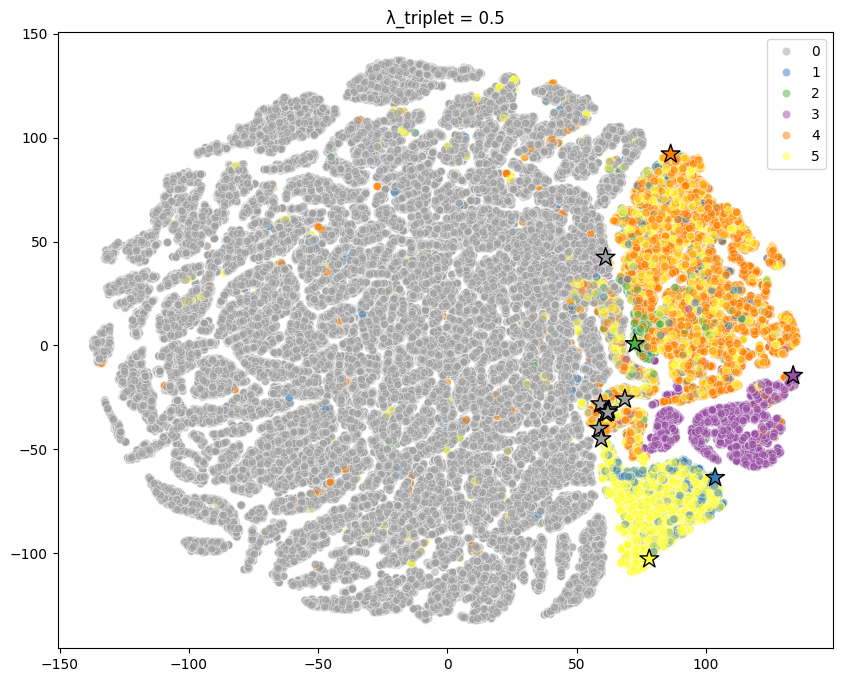

In [41]:
z_combined = np.vstack([z_sampled, prototypes])
tsne = TSNE(n_components=2)
embedding_combined = tsne.fit_transform(z_combined)

plt.figure(figsize=(10, 8))
sns.scatterplot(x=embedding_combined[:-15, 0], y=embedding_combined[:-15, 1], hue=y_train_anomalies_sampled, alpha=0.5, palette=custom_palette)

plt.scatter(embedding_combined[-15:, 0], embedding_combined[-15:, 1], c=proto_colors, marker='*', s=200, edgecolors='black')

plt.title("λ_triplet = 0.5")
plt.legend()
plt.savefig(f"figs/ppnet/triplet_lambda_0_5_sampled_tsne.png")
plt.show()

#### Testing data

In [53]:
reducer = umap.UMAP()
embedding = reducer.fit_transform(z_sampled)
print(embedding.shape)

/home/darosali/BP/amaretto/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


(69681, 2)


In [54]:
prototypes = model.proto_layer.prototypes.detach().cpu().numpy()
prototype_embedding = reducer.transform(prototypes) 
prototype_embedding.shape

/home/darosali/BP/amaretto/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


(15, 2)

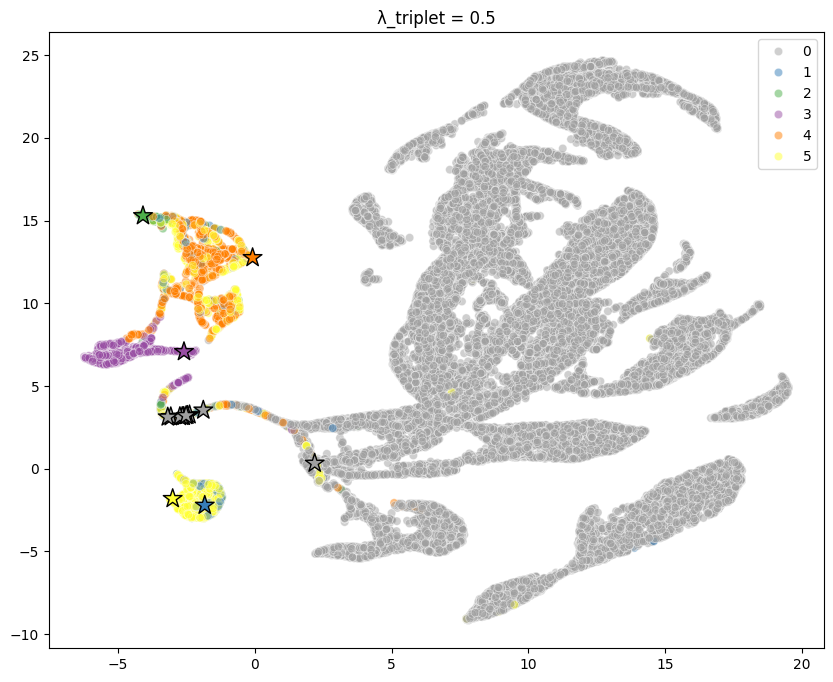

In [55]:
# Plot
plt.figure(figsize=(10, 8))
sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], hue=y_test_anomalies_sampled, alpha=0.5, palette=custom_palette)

plt.scatter(prototype_embedding[:, 0], prototype_embedding[:, 1], c=proto_colors, marker='*', s=200, edgecolors='black')

#plt.xlabel("UMAP Dimension 1")
#plt.ylabel("UMAP Dimension 2")
plt.title("λ_triplet = 0.5")
plt.legend()
#plt.savefig(f"figs/ppnet/triplet_lambda_0_5_sampled.png")
plt.show()

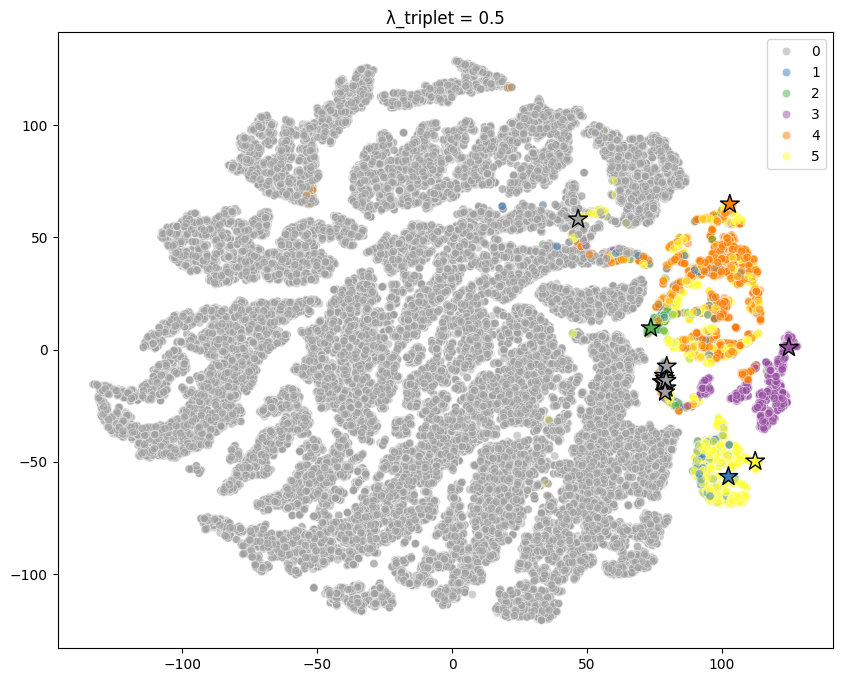

In [52]:
z_combined = np.vstack([z_sampled, prototypes])
tsne = TSNE(n_components=2)
embedding_combined = tsne.fit_transform(z_combined)

plt.figure(figsize=(10, 8))
sns.scatterplot(x=embedding_combined[:-15, 0], y=embedding_combined[:-15, 1], hue=y_test_anomalies_sampled, alpha=0.5, palette=custom_palette)

plt.scatter(embedding_combined[-15:, 0], embedding_combined[-15:, 1], c=proto_colors, marker='*', s=200, edgecolors='black')

plt.title("λ_triplet = 0.5")
plt.legend()
#plt.savefig(f"figs/ppnet/triplet_lambda_0_5_sampled_tsne.png")
plt.show()